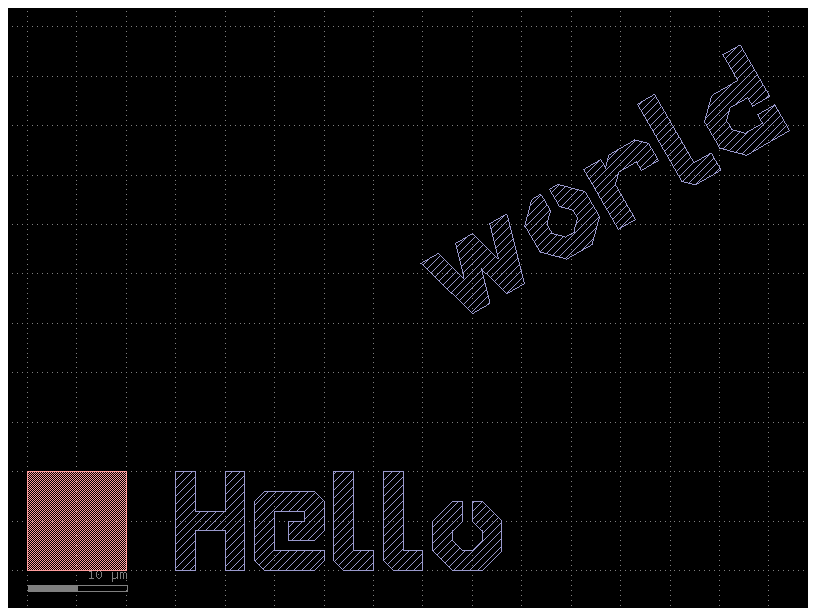

In [4]:
import gdsfactory as gf

# Create a new component
c = gf.Component()

# Add a rectangle
r = gf.components.rectangle(size=(10, 10), layer=(1, 0))
rect = c.add_ref(r)

# Add text elements
t1 = gf.components.text("Hello", size=10, layer=(4, 0))
t2 = gf.components.text("world", size=10, layer=(4, 0))

text1 = c.add_ref(t1)
text2 = c.add_ref(t2)

# Position elements
text1.xmin = rect.xmax + 5
text2.xmin = text1.xmax + 2
text2.rotate(30)

# Show the result
c.write_gds("layout.gds")
c.plot()

In [5]:
from gdsfactory.component import Component
def mzi_switch(straight_length: float = 35.0) -> Component:
    """
    Creates a basic 2x2 MZI switch with clearly named ports
    for routing ('in1', 'in2', 'out1', 'out2').

    Args:
        straight_length: The length of the straight sections in the MZI arms.
    """
    # Use the proper 4-pin MZI lattice component
    mzi_comp = gf.components.mzi_lattice(
        coupler_lengths=(10, 20),
        coupler_gaps=(0.2, 0.3),
        delta_lengths=(10,),
        mzi='mzi_coupler',
        splitter='coupler'
    ).copy()

    # Create a new component to wrap the MZI and rename its ports for clarity
    c = Component()
    mzi_ref = c << mzi_comp

    # Map the ports based on their positions:
    # o1: left bottom input -> in1
    # o2: left top input -> in2
    # o3: right top output -> out2
    # o4: right bottom output -> out1
    c.add_port('in1', port=mzi_ref.ports['o1'])
    c.add_port('in2', port=mzi_ref.ports['o2'])
    c.add_port('out1', port=mzi_ref.ports['o4'])
    c.add_port('out2', port=mzi_ref.ports['o3'])

    return c

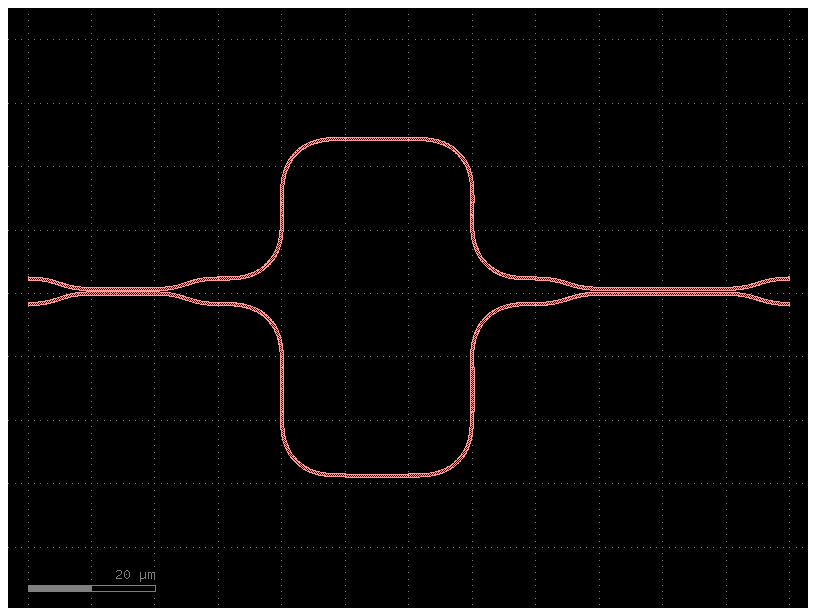

In [12]:
switch = mzi_switch()
switch.plot()
switch.show()